# 1. Vector addition and multiplication: preserve coordinate meaning

Learn to add vectors coordinate by coordinate, scale a vector by a scalar, distinguish elementwise products from dot products, and calculate weighted combinations. Prerequisite: [scalars, vectors, and matrices](../../../02_Mathematics_for_ML/07_scalars_vectors_and_matrices.ipynb). The main example uses invented two-dimensional movements in meters: east is coordinate zero and north is coordinate one. This shared coordinate system is part of the data contract.

## 2. What problem does this solve?

An observation or parameter set often contains several related numbers. A vector packages them in a defined order. Adding two vectors combines corresponding coordinates; scaling changes every coordinate by a common factor. These operations appear in feature transformations, weighted averages, and later parameter updates.

The risk is confusing numerical compatibility with semantic compatibility. A two-number vector ordered east/north cannot be added meaningfully to one ordered north/east without reordering. A Python list plus another list concatenates them rather than adding coordinates. We will calculate each operation by hand and verify code against its intended meaning.

## 3. Intuition and analogy

Imagine walking one meter east and two north, then three east and one south. The final displacement is four east and one north. Vector addition combines movements regardless of the order in which you take them, under this idealized flat coordinate system.

Scaling the first movement by two means going twice as far in both directions. Multiplying each coordinate by a different calibration factor is another operation: it stretches different directions differently. A dot product instead combines two vectors into one scalar. The word 'multiply' is ambiguous until you state which operation you mean.

## 4. Terminology

A **coordinate** is one component of a vector in a specified system. A **scalar** is one number. **Scalar multiplication** multiplies every coordinate by that number. An **elementwise** or **Hadamard product** multiplies matching coordinates and returns a vector. A **dot product** multiplies matching coordinates and sums them, returning a scalar; its dedicated lesson follows next.

A **linear combination** scales vectors and adds them. A **weighted average** uses nonnegative weights normalized to sum to one. A **zero vector** has every coordinate zero. An **additive inverse** negates every coordinate. A **shape** describes the numerical arrangement; our basic NumPy vectors use shape `(2,)`, not `(2,1)`.

## 5. Mathematical foundations

For vectors $u,v\in\mathbb{R}^d$, define

$$u+v=(u_0+v_0,\ldots,u_{d-1}+v_{d-1}),\qquad \alpha u=(\alpha u_0,\ldots,\alpha u_{d-1}).$$

$d$ is the number of coordinates; $\mathbb{R}^d$ means an ordered list of $d$ real numbers. $u_j$ and $v_j$ identify coordinate $j$, indexed from zero. $\alpha$ is a scalar. When $u$ and $v$ represent movements in meters in the same coordinate system, their sum is in meters. A dimensionless $\alpha$ leaves those units unchanged.

The elementwise product is $(u\odot v)_j=u_jv_j$, where $\odot$ names this particular multiplication. It has shape $(d,)$; multiplying two meter-valued coordinates yields meters squared. For dimensionless coordinate factors $s_j$, $s\odot u$ instead remains in meters. The weighted combination $z=\lambda u+(1-\lambda)v$ has shape $(d,)$ and lies between endpoint vectors for $0\leq\lambda\leq1$.

## 6. Hand-calculated example

Let $u=(1,2)$ and $v=(3,-1)$ meters in east/north order. Then $u+v=(1+3,2-1)=(4,1)$ meters. $2u=(2,4)$ meters. Negating $u$ gives $(-1,-2)$, and adding it to $u$ gives the zero movement.

For calibration factors $s=(2,0.5)$, $s\odot u=(2,1)$ meters. For two movement vectors, $u\odot v=(3,-2)$ meters squared; it is not the final displacement. The weighted average with $\lambda=0.25$ is $0.25u+0.75v=(0.25+2.25,0.5-0.75)=(2.5,-0.25)$ meters. One output has two coordinates, not one scalar.

## 7. Addition from scratch

Validate lengths before `zip`, because `zip` stops at the shorter input. The helper snapshots input iterables and accepts finite ordinary Python numbers, excluding booleans. It returns a new list so callers retain the original vectors. This is a teaching interface; NumPy supports broader array types.

In [1]:
# Enable embedded figures in this fresh notebook kernel.
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')

In [2]:
import math

def add_vectors(left, right):
    first, second = list(left), list(right)
    if not first or len(first) != len(second):
        raise ValueError('Use nonempty vectors of equal length.')
    for value in first + second:
        if isinstance(value, bool) or not isinstance(value, (int, float)) or not math.isfinite(value):
            raise ValueError('Use finite ordinary numerical coordinates.')
    return [a + b for a, b in zip(first, second)]

u_list, v_list = [1.0, 2.0], [3.0, -1.0]
added = add_vectors(u_list, v_list)
scaled = [2.0 * coordinate for coordinate in u_list]
calibrated = [factor * coordinate for factor, coordinate in zip([2.0, 0.5], u_list)]
assert added == [4.0, 1.0] and scaled == [2.0, 4.0] and calibrated == [2.0, 1.0]
assert u_list == [1.0, 2.0] and v_list == [3.0, -1.0]
print('Added:', added, 'Scaled:', scaled, 'Calibrated:', calibrated)

Added: [4.0, 1.0] Scaled: [2.0, 4.0] Calibrated: [2.0, 1.0]


## 8. Inspect Python versus mathematical operations

In [3]:
concatenated = u_list + v_list
assert concatenated == [1.0, 2.0, 3.0, -1.0]
assert len(concatenated) == 4 and len(added) == 2
silently_short = [a + b for a, b in zip([1, 2], [3])]
assert silently_short == [4]
try:
    add_vectors([1, 2], [3])
except ValueError as error:
    print('Mismatched lengths rejected:', error)
else:
    raise AssertionError('Length mismatch was silently truncated.')
print('List + concatenates:', concatenated)

Mismatched lengths rejected: Use nonempty vectors of equal length.
List + concatenates: [1.0, 2.0, 3.0, -1.0]


Python syntax depends on operand types. The same plus sign performs list concatenation or NumPy coordinate addition. Inspect types and shapes before interpreting a result as vector arithmetic. A one-coordinate output is not a corrected version of a mismatched two-coordinate input.

## 9. NumPy implementation and weighted-average library

In [4]:
import numpy as np
u, v = np.array(u_list), np.array(v_list)
factors = np.array([2.0, 0.5])
assert u.shape == v.shape == factors.shape == (2,)
np.testing.assert_array_equal(u + v, added)
np.testing.assert_array_equal(2 * u, scaled)
np.testing.assert_array_equal(factors * u, calibrated)
np.testing.assert_array_equal(u * v, [3.0, -2.0])
weighted = 0.25 * u + 0.75 * v
library_weighted = np.average(np.stack([u, v]), axis=0, weights=[0.25, 0.75])
np.testing.assert_allclose(weighted, [2.5, -0.25])
np.testing.assert_allclose(weighted, library_weighted)
print('Elementwise movement product:', u * v, 'meters squared')
print('Weighted point:', weighted, 'meters')

Elementwise movement product: [ 3. -2.] meters squared
Weighted point: [ 2.5  -0.25] meters


`np.stack([u,v])` produces a table with shape `(2,2)`: rows identify vectors and columns identify east/north coordinates. Averaging along `axis=0` combines those rows and leaves one two-coordinate output. NumPy's `*` on these arrays is elementwise; a dot product will use a different explicit operation in the next lesson.

## 10. Visualization

Draw the first movement from the origin and the second from its endpoint. Their combined displacement reaches `(4,1)`. The weighted point lies on the segment joining the two vector endpoints, a different construction from adding movements. Equal axis scaling makes one meter look the same horizontally and vertically.

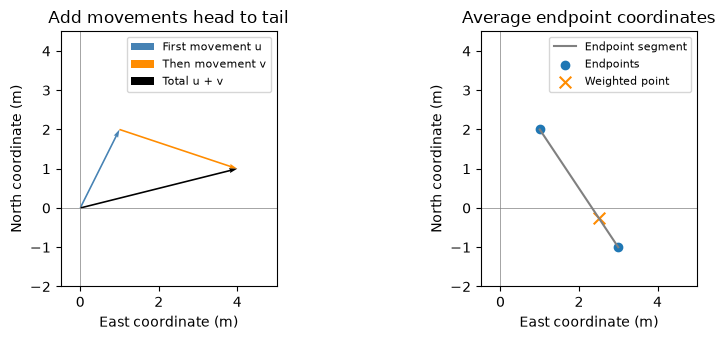

In [5]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
def arrow(axis, origin, movement, color, label):
    axis.quiver(*origin, *movement, angles='xy', scale_units='xy', scale=1, color=color, label=label)
arrow(axes[0], [0, 0], u, 'steelblue', 'First movement u')
arrow(axes[0], u, v, 'darkorange', 'Then movement v')
arrow(axes[0], [0, 0], u + v, 'black', 'Total u + v')
axes[1].plot([u[0], v[0]], [u[1], v[1]], color='gray', label='Endpoint segment')
axes[1].scatter([u[0], v[0]], [u[1], v[1]], label='Endpoints')
axes[1].scatter([weighted[0]], [weighted[1]], marker='x', color='darkorange', s=70, label='Weighted point')
for axis in axes:
    axis.set(xlabel='East coordinate (m)', ylabel='North coordinate (m)', xlim=(-0.5, 5), ylim=(-2, 4.5), aspect='equal')
    axis.axhline(0, color='gray', linewidth=0.5)
    axis.axvline(0, color='gray', linewidth=0.5)
    axis.legend(fontsize=8, loc='upper right')
axes[0].set_title('Add movements head to tail')
axes[1].set_title('Average endpoint coordinates')
fig.tight_layout()
display(fig)
plt.close(fig)

## 11. Experiment: a short movement sequence

Combine three invented movements and inspect cumulative positions after each. The movement table has shape `(3,2)`, and the cumulative position table has the same shape. Summing across rows gives final displacement `(3,2)`. This is a deterministic coordinate calculation, not an estimated tracking model.

In [6]:
movements = np.array([[1.0, 2.0], [3.0, -1.0], [-1.0, 1.0]])
position = [0.0, 0.0]
manual_positions = []
for movement in movements.tolist():
    position = add_vectors(position, movement)
    manual_positions.append(position)
positions = np.cumsum(movements, axis=0)
np.testing.assert_array_equal(positions, manual_positions)
np.testing.assert_array_equal(movements.sum(axis=0), [3.0, 2.0])
assert positions.shape == movements.shape == (3, 2)
print('Positions after each movement:\n', positions)

Positions after each movement:
 [[1. 2.]
 [4. 1.]
 [3. 2.]]


## 12. Weights, coordinate order, and configuration

Coordinates, calibration factors, and weights are supplied here; nothing is learned. If later weights are estimated from data, training and validation rules become relevant. A negative weight is legal in a linear combination but does not describe an ordinary weighted average with nonnegative contributions. Weights summing to one preserve an endpoint-average interpretation; arbitrary sums need a different explanation.

## 13. Evaluation

Check hand arithmetic, equal lengths, coordinate order, unchanged inputs, and basic identities. Addition is commutative: $u+v=v+u$. Scaling distributes over addition: $\alpha(u+v)=\alpha u+\alpha v$. Numerical equality may require tolerance for general floating-point values. Neither identity can detect a semantically swapped coordinate system, so retain names and units separately.

In [7]:
np.testing.assert_allclose(u + v, v + u)
np.testing.assert_allclose(2 * (u + v), 2 * u + 2 * v)
np.testing.assert_allclose(u + (-u), [0, 0])
np.testing.assert_array_equal(u, u_list)
for left, right in [([], []), ([True], [1]), ([math.nan], [1])]:
    try:
        add_vectors(left, right)
    except ValueError:
        pass
    else:
        raise AssertionError('Invalid vectors were accepted.')
print('Addition identities and invalid-input checks passed.')

Addition identities and invalid-input checks passed.


## 14. Assumptions and limitations

Movement coordinates share units, reference frame, and ordering. Latitude and longitude cannot be treated as equal-meter flat coordinates without appropriate geographical treatment. A feature vector may mix units across coordinates; addition can still be meaningful coordinate by coordinate, while a geometric length across mixed units needs careful scaling and interpretation. Extreme finite numbers can overflow; our helper is not an arbitrary-precision geometry library.

## 15. Common mistakes and debugging

Avoid list concatenation when you intend coordinate addition. Validate equal length before a scratch `zip` implementation. Do not assume `(2,)` and `(2,1)` have interchangeable arithmetic: broadcasting them can create a `(2,2)` result. Check shape before and after multiplication. Do not call a Hadamard product a dot product or attach meter units to a product that actually has meters squared.

Coordinate labels matter even when shapes match. Reordering north/east silently changes which quantities combine. A labeled pandas structure can help track meaning, but its alignment rules must also be understood.

## 16. Alternatives and connections

Plain lists expose arithmetic but require careful length and type validation. NumPy supplies efficient consistent array operations. Labeled tables help preserve coordinate names. Scalar multiplication changes an entire vector by one factor; diagonal coordinate scaling changes individual axes; dot products produce scalar projections or weighted sums. Matrix multiplication later combines many such weighted sums at once.

## 17. Exercises

- **Beginner:** Add `(2,-3)` and `(-1,5)` in a common meter coordinate system.
- **Beginner:** Scale `(2,-3)` by minus two and explain the direction change.
- **Beginner:** Calculate the elementwise product of dimensionless `(2,3)` and `(4,5)` and state its output shape.
- **Intermediate:** Calculate the midpoint of `u` and `v` and compare it with their sum.
- **Intermediate:** Explain why east/north and north/east vectors require reordering before addition.
- **Challenge:** Implement a checked nonnegative weighted average of several same-length vectors. Reject mismatched dimensions, invalid coordinates, negative weights, or zero total weight. Compare with NumPy and prove a common weight scaling leaves the result unchanged.

## 18. Detailed solutions

The sum is `(1,2)` meters. Multiplying `(2,-3)` by minus two gives `(-4,6)` meters, reversing direction and doubling magnitude. The elementwise product is `(8,15)` with shape `(2,)`, not a scalar. The midpoint of `u` and `v` is `(2,0.5)` meters, half their sum `(4,1)`. Coordinates must refer to matching axes before corresponding entries can be added.

For vectors $v_i$ with weights $w_i\geq0$ and positive total $W=\sum_iw_i$, the average is $z_j=\sum_iw_iv_{i,j}/W$. Here $i$ identifies a vector and $j$ a coordinate. Weight scaling cancels between numerator and denominator. This supports relative weights such as one and three rather than requiring pre-normalized fractions.

In [8]:
def checked_vector_average(vectors, weights):
    table = [list(vector) for vector in vectors]
    w = list(weights)
    if not table or not table[0] or len(table) != len(w):
        raise ValueError('Use nonempty vectors with one weight each.')
    width = len(table[0])
    if any(len(row) != width for row in table):
        raise ValueError('All vector dimensions must match.')
    flattened = [value for row in table for value in row] + w
    if any(isinstance(value, bool) or not isinstance(value, (int, float)) or not math.isfinite(value) for value in flattened):
        raise ValueError('Use finite ordinary numerical coordinates and weights.')
    if any(weight < 0 for weight in w) or sum(w) <= 0:
        raise ValueError('Weights must be nonnegative with positive total.')
    return [math.fsum(weight * row[j] for row, weight in zip(table, w)) / math.fsum(w) for j in range(width)]

assert add_vectors([2, -3], [-1, 5]) == [1, 2]
np.testing.assert_array_equal(-2 * np.array([2, -3]), [-4, 6])
np.testing.assert_array_equal(np.array([2, 3]) * [4, 5], [8, 15])
np.testing.assert_allclose(0.5 * u + 0.5 * v, [2, 0.5])
answer = checked_vector_average([u_list, v_list], [1, 3])
np.testing.assert_allclose(answer, weighted)
np.testing.assert_allclose(answer, checked_vector_average([u_list, v_list], [10, 30]))
for table, weights in [([[1], [2, 3]], [1, 1]), ([[1], [2]], [-1, 2]), ([[1]], [0]), ([[math.nan]], [1])]:
    try:
        checked_vector_average(table, weights)
    except ValueError:
        pass
    else:
        raise AssertionError('Invalid weighted-average input was accepted.')
print('Vector and checked-weighted-average exercises passed.')

Vector and checked-weighted-average exercises passed.


## 19. Knowledge check

**What must match before adding vectors?** Coordinate count, ordering, units, and reference meaning.

**What does NumPy star do to two same-shaped vectors?** Elementwise multiplication, returning another vector.

**What does a scalar multiplier change?** Every coordinate by the same factor, with units determined by that factor.

**Does a matching shape guarantee meaning?** No. Coordinate order or units can still be wrong.

**Why validate lengths before zip?** Zip stops at the shorter input and can silently drop coordinates.

## 20. Interview preparation

**How does scalar multiplication differ from a dot product?** One scales a vector and returns a vector; the other sums coordinate products into a scalar.

**What is a linear combination?** A sum of vectors multiplied by scalar coefficients.

**When is a linear combination a weighted average?** With nonnegative normalized weights, or after dividing nonnegative weights by their positive total.

**How can broadcasting corrupt vector arithmetic?** A column and flat vector can expand into an unintended matrix of pairwise operations.

**How would you test a vector helper?** Use manual coordinates, shape/type failures, nonmutation checks, and identities such as commutativity and distributivity.

## 21. Summary and next steps

State which multiplication you mean, combine matching coordinates, and keep units visible. Weighted averages normalize contributions rather than simply adding endpoints. Continue to [dot products](../../../02_Mathematics_for_ML/README.md#02-09), currently planned, for scalar weighted sums and geometric interpretation.